## Intervention on Restatement during GPT-OSS' Vanilla Reasoning

In [1]:
%load_ext autoreload
%autoreload 2

### Overview

This tutorial aims to reproduce one key result of [the Boundless DAS paper](https://arxiv.org/pdf/2305.08809). It uses the same pricing tag dataset as in the paper. Additionally, it focuses on finding alignment for the left boundary check only. 

### Set-up

In [2]:
import torch
import gc
import pandas as pd
from tqdm import tqdm
import random

import sys
sys.path.append("src")
import _util
import _dataset
from _intervention import prepare_batch_multitoken_intervention, batch_intervene, get_attention_freeze_hooks

In [3]:
_util.print_GPU_availbility()

CUDA is available: True
Available devices:
  GPU 0: NVIDIA GeForce RTX 3090
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |  

In [4]:
model_type = "GPT-OSS"
model, tokenizer = _util.load_OSS()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

## Prompt Templates

In [5]:
system_prompt = '''<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|>'''

user_question = '''<|start|>user<|message|>What is {num1}+{num2}?<|end|>'''

reasoning = '''<|start|>assistant<|channel|>analysis<|message|>The user asks: "What is {num1}+{num2}?" This is a simple arithmetic question. {num1}+{num2}='''

reasoning = '''<|start|>assistant<|channel|>analysis<|message|>We need to answer the question: "What is {num1}+{num2}?" The answer is '''

In [6]:
random.seed(42)

add_ds = _dataset.create_h2_dataset(num_digits=2, num_samples=256)

In [ ]:
# from openai_harmony import (
#     Author,
#     Conversation,
#     DeveloperContent,
#     HarmonyEncodingName,
#     Message,
#     Role,
#     SystemContent,
#     ToolDescription,
#     load_harmony_encoding,
#     ReasoningEffort
# )
 
# encoding = load_harmony_encoding(HarmonyEncodingName.HARMONY_GPT_OSS)
 
# system_message = (
#     SystemContent.new()
#         .with_reasoning_effort(ReasoningEffort.HIGH)
#         .with_conversation_start_date("2025-06-28")
# )
 
# convo = Conversation.from_messages(
#     [
#         Message.from_role_and_content(Role.SYSTEM, system_message),
#         Message.from_role_and_content(Role.USER, "What is 4153+7285?"),
#     ]
# )
 
# tokens = encoding.render_conversation_for_completion(convo, Role.ASSISTANT)
# print(tokenizer.decode(tokens))
# print(tokenizer.convert_ids_to_tokens(tokens))

<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 4153+7285?<|end|><|start|>assistant
['<|start|>', 'system', '<|message|>', 'You', 'Ġare', 'ĠChat', 'GPT', ',', 'Ġa', 'Ġlarge', 'Ġlanguage', 'Ġmodel', 'Ġtrained', 'Ġby', 'ĠOpen', 'AI', '.Ċ', 'Knowledge', 'Ġcutoff', ':', 'Ġ', '202', '4', '-', '06', 'Ċ', 'Current', 'Ġdate', ':', 'Ġ', '202', '5', '-', '06', '-', '28', 'ĊĊ', 'Reason', 'ing', ':', 'Ġhigh', 'ĊĊ', '#', 'ĠValid', 'Ġchannels', ':', 'Ġanalysis', ',', 'Ġcommentary', ',', 'Ġfinal', '.', 'ĠChannel', 'Ġmust', 'Ġbe', 'Ġincluded', 'Ġfor', 'Ġevery', 'Ġmessage', '.', '<|end|>', '<|start|>', 'user', '<|message|>', 'What', 'Ġis', 'Ġ', '415', '3', '+', '728', '5', '?', '<|end|>', '<|start|>', 'assistant']


In [ ]:
# for add_ds_entry in add_ds[:10]:
#     input_prompt = system_prompt + user_question.format(num1=add_ds_entry["base_1_num"], num2=add_ds_entry["base_2_num"])
#     tokens = tokenizer(input_prompt, return_tensors="pt").to(model.device)
#     # Generate for the entire batch
#     generations = model.generate(
#         tokens.input_ids,
#         attention_mask=tokens.attention_mask,
#         max_new_tokens=512,
#         do_sample=False,
#         pad_token_id=tokenizer.pad_token_id,
#     )
#     print(tokenizer.decode(generations[0]))

<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high
=
# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 20+54?<|end|><|start|>analysis<|message|>We need to answer the question: "What is 20+54?" The answer is 74. But we should consider if there's any trick. The user asks "What is 20+54?" It's a simple arithmetic addition. The sum is 74. So answer: 74. Probably just that.<|end|><|start|>final<|message|>74<|return|>
<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high
=
# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 31+92?<|end|><|start|>analysis<|message|>We need to answer the question: "What is 31+92?" The sum is 123. So answer: 12

In [7]:
def get_prompt(num1, num2):
    return (system_prompt + user_question + reasoning).format(num1=num1, num2=num2)

In [8]:
prompt = get_prompt(add_ds[0]["base_1_num"], add_ds[0]["base_2_num"])
print(prompt)

<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 20+54?<|end|><|start|>assistant<|channel|>analysis<|message|>We need to answer the question: "What is 20+54?" The answer is 


In [11]:
patch_ds = []
for add_ds_entry in add_ds:
    patch_ds.append([add_ds_entry["base_1_num"], add_ds_entry["base_2_num"], add_ds_entry["source_1_num"], add_ds_entry["source_2_num"], add_ds_entry["base_sum"], add_ds_entry["source_sum"], get_prompt(add_ds_entry["base_1_num"], add_ds_entry["base_2_num"]), get_prompt(add_ds_entry["source_1_num"], add_ds_entry["source_2_num"])])

# Convert patch_ds to pandas DataFrame
patch_ds = pd.DataFrame(patch_ds, columns=['base_1_num', 'base_2_num', 'source_1_num', 'source_2_num', 'base_sum', 'source_sum', 'base_prompt', 'source_prompt'])

In [10]:
for i, row in patch_ds.iterrows():
    tokens = tokenizer(row["base_prompt"], return_tensors="pt").to(model.device)
    print(list(enumerate(tokenizer.convert_ids_to_tokens(tokens["input_ids"][0]))))
    print(len(tokens["input_ids"][0]))


[(0, '<|start|>'), (1, 'system'), (2, '<|message|>'), (3, 'You'), (4, 'Ġare'), (5, 'ĠChat'), (6, 'GPT'), (7, ','), (8, 'Ġa'), (9, 'Ġlarge'), (10, 'Ġlanguage'), (11, 'Ġmodel'), (12, 'Ġtrained'), (13, 'Ġby'), (14, 'ĠOpen'), (15, 'AI'), (16, '.Ċ'), (17, 'Knowledge'), (18, 'Ġcutoff'), (19, ':'), (20, 'Ġ'), (21, '202'), (22, '4'), (23, '-'), (24, '06'), (25, 'Ċ'), (26, 'Current'), (27, 'Ġdate'), (28, ':'), (29, 'Ġ'), (30, '202'), (31, '5'), (32, '-'), (33, '06'), (34, '-'), (35, '28'), (36, 'ĊĊ'), (37, 'Reason'), (38, 'ing'), (39, ':'), (40, 'Ġhigh'), (41, 'ĊĊ'), (42, '#'), (43, 'ĠValid'), (44, 'Ġchannels'), (45, ':'), (46, 'Ġanalysis'), (47, ','), (48, 'Ġcommentary'), (49, ','), (50, 'Ġfinal'), (51, '.'), (52, 'ĠChannel'), (53, 'Ġmust'), (54, 'Ġbe'), (55, 'Ġincluded'), (56, 'Ġfor'), (57, 'Ġevery'), (58, 'Ġmessage'), (59, '.'), (60, '<|end|>'), (61, '<|start|>'), (62, 'user'), (63, '<|message|>'), (64, 'What'), (65, 'Ġis'), (66, 'Ġ'), (67, '20'), (68, '+'), (69, '54'), (70, '?'), (71, '<|en

### Intervention

In [12]:
tok_pos_list = [90]

header = ['layer'] + list(patch_ds.columns) + ['generated_text', 'is_factual', 'is_counterfactual']
filepath = _util.create_csv_file(f"experiments/activation_intervention/output/{model_type}/vanilla_layer", f"restatement_layerwise.csv", header, overwrite=False)


for layer in range(len(model.model.layers)):
    batch_size = 24

    for i in tqdm(range(0, len(patch_ds), batch_size)):
        torch.cuda.empty_cache()
        gc.collect()
        batch_rows = patch_ds.iloc[i:i+batch_size]

        tokens, hook = prepare_batch_multitoken_intervention(model, tokenizer, layer, tok_pos_list, batch_rows['base_prompt'].tolist(), batch_rows['source_prompt'].tolist())
        input_length = tokens["input_ids"].shape[1]

        for j in range(2):
            # attention_freeze_hooks = get_attention_freeze_hooks(model, tokens)
            with torch.no_grad():
                output = batch_intervene(model, tokens["input_ids"], [hook], attention_mask=tokens["attention_mask"]) # attention_freeze_hooks + 
            pred_toks = output.logits[:,-1,:].argmax(dim=-1)
            tokens["input_ids"] = torch.cat([tokens["input_ids"], pred_toks.unsqueeze(-1)], dim=1)
            del output
        
        for j, (_, row) in enumerate(batch_rows.iterrows()):
            generated_text = tokenizer.decode(tokens["input_ids"][j,input_length:]).replace(tokenizer.pad_token[-1], "")
            is_factual = str(row["base_sum"]) in generated_text
            is_counterfactual = str(row["source_sum"]) in generated_text
            _util.write_to_csv(filepath, [layer] + row.to_list() + [generated_text, is_factual, is_counterfactual])

        del tokens, hook
        torch.cuda.empty_cache()
        gc.collect()

  0%|                                                                                          | 0/11 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████| 11/11 [01:11<00:00,  6.51s/it]


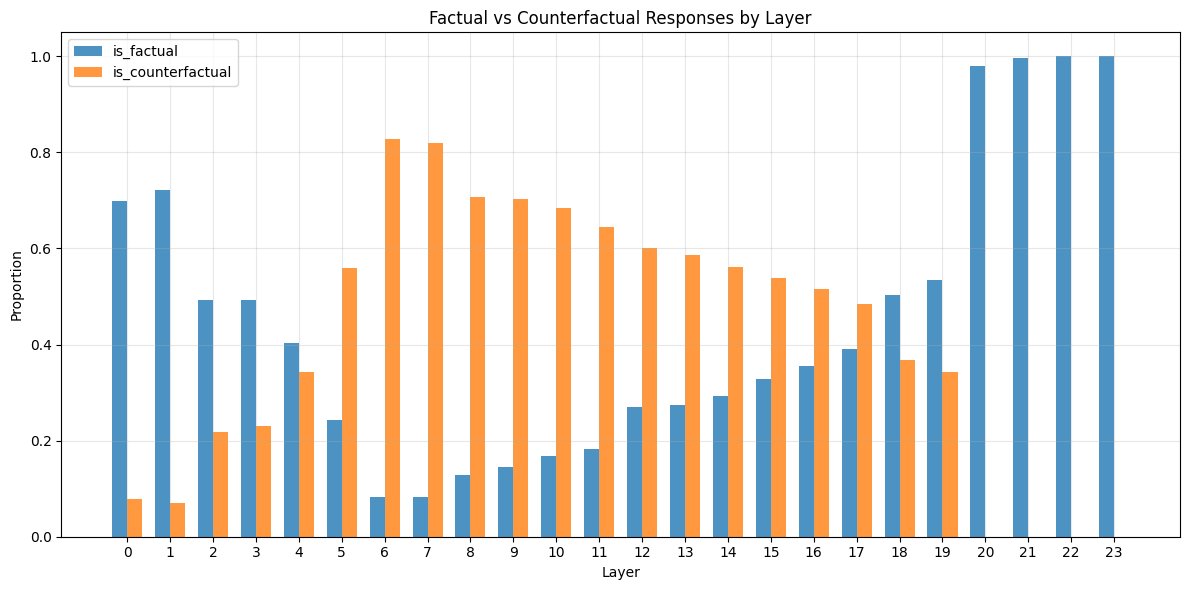

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("experiments/activation_intervention/output/GPT-OSS/vanilla_layer/restatement_layerwise_1.csv")

# Group by layer and calculate the mean of is_factual and is_counterfactual
layer_stats = df.groupby('layer')[['is_factual', 'is_counterfactual']].mean()

# Create bar chart
plt.figure(figsize=(12, 6))
x = range(len(layer_stats.index))
width = 0.35

plt.bar([i - width/2 for i in x], layer_stats['is_factual'], width, label='is_factual', alpha=0.8)
plt.bar([i + width/2 for i in x], layer_stats['is_counterfactual'], width, label='is_counterfactual', alpha=0.8)

plt.xlabel('Layer')
plt.ylabel('Proportion')
plt.title('Factual vs Counterfactual Responses by Layer')
plt.xticks(x, layer_stats.index)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
tok_pos_list = [90]

header = list(patch_ds.columns) + ['generated_text', 'is_factual', 'is_counterfactual']
filepath = _util.create_csv_file(f"experiments/activation_intervention/output/{model_type}/vanilla_layer", f"2_digit_restatement_all_layer.csv", header, overwrite=False)

batch_size = 24
for i in tqdm(range(0, len(patch_ds), batch_size)):
    torch.cuda.empty_cache()
    gc.collect()
    batch_rows = patch_ds.iloc[i:i+batch_size]
    
    hooks = []
    for layer in range(len(model.model.layers)):
        tokens, hook = prepare_batch_multitoken_intervention(model, tokenizer, layer, tok_pos_list, batch_rows['base_prompt'].tolist(), batch_rows['source_prompt'].tolist())
        hooks.append(hook)
    input_length = tokens["input_ids"].shape[1]

    for j in range(2):
        # attention_freeze_hooks = get_attention_freeze_hooks(model, tokens)
        with torch.no_grad():
            output = batch_intervene(model, tokens["input_ids"], hooks, attention_mask=tokens["attention_mask"]) # attention_freeze_hooks + 
        pred_toks = output.logits[:,-1,:].argmax(dim=-1)
        tokens["input_ids"] = torch.cat([tokens["input_ids"], pred_toks.unsqueeze(-1)], dim=1)
        del output
    
    for j, (_, row) in enumerate(batch_rows.iterrows()):
        generated_text = tokenizer.decode(tokens["input_ids"][j,input_length:]).replace(tokenizer.pad_token[-1], "")
        is_factual = str(row["base_sum"]) in generated_text
        is_counterfactual = str(row["source_sum"]) in generated_text
        _util.write_to_csv(filepath, row.to_list() + [generated_text, is_factual, is_counterfactual])

    del tokens, hook
    torch.cuda.empty_cache()
    gc.collect()

100%|█████████████████████████████████████████████████████████████████████████████████| 11/11 [09:58<00:00, 54.40s/it]


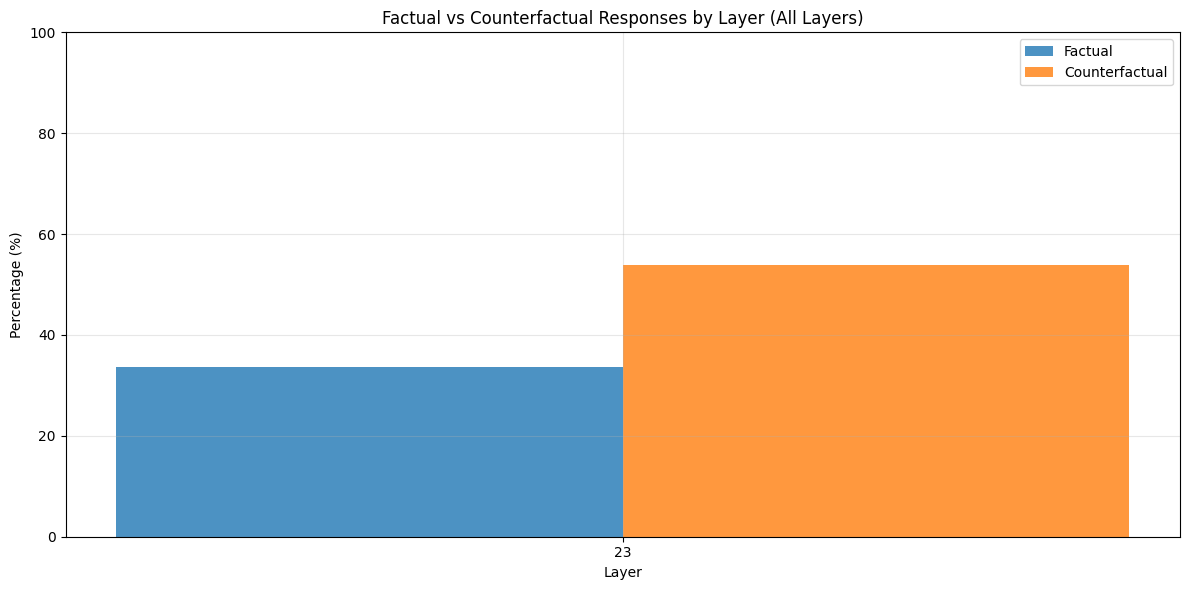

Summary Statistics:
       factual_percentage  counterfactual_percentage
layer                                               
23               33.59375                   53.90625


In [18]:
import numpy as np

# Read the results and analyze factual vs counterfactual responses
results_df = pd.read_csv("experiments/activation_intervention/output/GPT-OSS/vanilla_layer/2_digit_restatement_all_layer.csv")

# Calculate percentages by layer
layer_stats = results_df.groupby('layer').agg({
    'is_factual': ['sum', 'count'],
    'is_counterfactual': ['sum', 'count']
}).round(4)

# Flatten column names
layer_stats.columns = ['factual_count', 'total_count', 'counterfactual_count', 'total_count2']

# Calculate percentages
layer_stats['factual_percentage'] = (layer_stats['factual_count'] / layer_stats['total_count']) * 100
layer_stats['counterfactual_percentage'] = (layer_stats['counterfactual_count'] / layer_stats['total_count']) * 100

# Plot the results
plt.figure(figsize=(12, 6))
x = np.arange(len(layer_stats))
width = 0.35

plt.bar(x - width/2, layer_stats['factual_percentage'], width, label='Factual', alpha=0.8)
plt.bar(x + width/2, layer_stats['counterfactual_percentage'], width, label='Counterfactual', alpha=0.8)

plt.xlabel('Layer')
plt.ylabel('Percentage (%)')
plt.title('Factual vs Counterfactual Responses by Layer (All Layers)')
plt.xticks(x, layer_stats.index)
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
print(layer_stats[['factual_percentage', 'counterfactual_percentage']])
